# Chapter 1: Why Knowledge Graphs?

**Level 1: Foundations** · ⏱ about 1.5 hours · Dataset: *Company / people*

### What you will learn

By the end of this chapter you can:

1. Explain what a **knowledge graph** is and which questions it answers better than tables
2. Describe the **RDF triple model** and read Turtle, the most common RDF format
3. Explain why RDF uses **IRIs and namespaces**, and how that makes data integration easy
4. Compare **RDF with property graphs** (Neo4j)
5. Explain the difference between the **open world** and **closed world** assumptions
6. Name the parts of the **Stardog platform** and what each one is for
7. Load data into **Stardog Cloud** and run your first query from Python and from Studio

### Before you start

- A Stardog Cloud account, with a `.env` file in the project root (see `00_setup/.env.example`)
- The project's `.venv` selected as this notebook's kernel (VS Code: *Select Kernel → Python Environments → .venv*)

Most of this chapter runs **locally** with `rdflib`, a pure Python RDF library, so you can learn the ideas without a server. Stardog comes in at the end.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from rdflib import Graph, Literal, Namespace, RDF, URIRef

DATA = Path('..') / 'data' / 'company' / 'company.ttl'
CO = Namespace('http://example.org/company#')
print('Dataset:', DATA.resolve())

Dataset: D:\learning\stardog\stardog_tutorial\data\company\company.ttl


## 1.1 The problem with tables

Here is some company data the way a relational database would hold it: a table of people, a table of companies, and a **join table** for "who knows whom".

In [2]:
people = pd.DataFrame({
    'person_id': ['alice', 'bob', 'carol', 'dave', 'eve'],
    'name':      ['Alice', 'Bob', 'Carol', 'Dave', 'Eve'],
    'company_id': ['acme', 'acme', 'globex', 'initech', 'globex'],
    'role': ['Data Engineer', 'Manager', 'Data Scientist', 'Architect', 'Analyst'],
})
companies = pd.DataFrame({
    'company_id': ['acme', 'globex', 'initech'],
    'name': ['Acme Corp', 'Globex Ltd', 'Initech'],
    'city': ['Bengaluru', 'Pune', 'Hyderabad'],
})
knows = pd.DataFrame({
    'person_id': ['alice', 'alice', 'bob', 'carol', 'eve', 'eve'],
    'knows_id':  ['bob', 'carol', 'dave', 'alice', 'carol', 'dave'],
})
display(people, companies, knows)

,person_id,name,company_id,role
0,alice,Alice,acme,Data Engineer
1,bob,Bob,acme,Manager
2,carol,Carol,globex,Data Scientist
3,dave,Dave,initech,Architect
4,eve,Eve,globex,Analyst


,company_id,name,city
0,acme,Acme Corp,Bengaluru
1,globex,Globex Ltd,Pune
2,initech,Initech,Hyderabad


,person_id,knows_id
0,alice,bob
1,alice,carol
2,bob,dave
3,carol,alice
4,eve,carol
5,eve,dave


Now a typical **relationship question**:

> *"Who can Eve reach through her network, at any distance, and where do they work?"*

Tables have no notion of "follow links until you run out". We have to write the traversal ourselves:

In [3]:
def reachable(start):
    seen, frontier = set(), {start}
    while frontier:                                    # repeat until no new people are found
        found = set(knows[knows.person_id.isin(frontier)].knows_id)
        frontier = found - seen - {start}
        seen |= frontier
    return seen

result = (people[people.person_id.isin(reachable('eve'))]
          .merge(companies, on='company_id', suffixes=('', '_company'))
          [['name', 'name_company', 'city']])
result

,name,name_company,city
0,Alice,Acme Corp,Bengaluru
1,Bob,Acme Corp,Bengaluru
2,Carol,Globex Ltd,Pune
3,Dave,Initech,Hyderabad


In SQL this needs a **recursive CTE**:

```sql
WITH RECURSIVE reach(person_id) AS (
  SELECT knows_id FROM knows WHERE person_id = 'eve'
  UNION
  SELECT k.knows_id FROM knows k JOIN reach r ON k.person_id = r.person_id
)
SELECT p.name, c.name, c.city
FROM reach JOIN people p USING (person_id) JOIN companies c USING (company_id)
WHERE p.person_id <> 'eve';
```

It works, but the **relationships are the hard part**, and relationships are exactly what many real questions are about: supply chains, fraud rings, drug interactions, org charts, prerequisites.

A **knowledge graph** makes relationships first-class: they are stored and queried directly.

## 1.2 Thinking in graphs

The same data as a graph: **things** (nodes) connected by **named relationships** (edges).

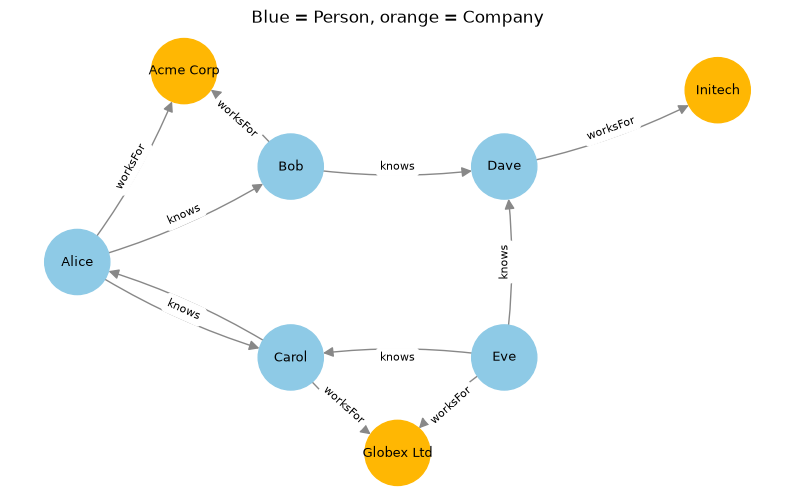

In [4]:
G = nx.DiGraph()
for p in people.itertuples():
    G.add_node(p.name, kind='Person')
for c in companies.itertuples():
    G.add_node(c.name, kind='Company')
names = dict(zip(people.person_id, people.name)) | dict(zip(companies.company_id, companies.name))
for p in people.itertuples():
    G.add_edge(p.name, names[p.company_id], label='worksFor')
for k in knows.itertuples():
    G.add_edge(names[k.person_id], names[k.knows_id], label='knows')

pos = {'Alice': (0, 1), 'Bob': (1, 2), 'Carol': (1, 0), 'Dave': (2, 2), 'Eve': (2, 0),
       'Acme Corp': (0.5, 3), 'Globex Ltd': (1.5, -1), 'Initech': (3, 2.8)}
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#8ecae6' if G.nodes[n]['kind'] == 'Person' else '#ffb703' for n in G.nodes]
nx.draw_networkx(G, pos, ax=ax, node_color=colors, node_size=2200, font_size=9,
                 arrowsize=15, edge_color='#888888', connectionstyle='arc3,rad=0.08')
nx.draw_networkx_edge_labels(G, pos, ax=ax, font_size=8,
                             edge_labels=nx.get_edge_attributes(G, 'label'))
ax.set_title('Blue = Person, orange = Company')
ax.axis('off')
plt.show()

Reading the question off the picture is easy: start at **Eve**, follow `knows` arrows, collect everyone you hit. A graph database does exactly that, and the query language has a built-in operator for it.

## 1.3 The RDF triple model

**RDF** (Resource Description Framework) is the W3C standard data model Stardog uses. It has exactly one building block, the **triple**:

```
subject    predicate    object
co:alice   co:worksFor  co:acme .
co:alice   co:name      "Alice" .
```

- The **subject** is the thing we're talking about.
- The **predicate** is the property or relationship.
- The **object** is either another thing (an **IRI**, making an *edge*) or a value (a **literal**, making an *attribute*).

Everything is a triple: relationships, attributes, and even the *type* of a thing (`co:alice rdf:type co:Person`, written `a` in Turtle).

### Turtle

The chapter's dataset is in **Turtle** (`.ttl`), the most readable RDF format:

In [5]:
print(DATA.read_text())

# Company / people dataset used in Chapters 1 and 2.
@prefix co:   <http://example.org/company#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd:  <http://www.w3.org/2001/XMLSchema#> .

# Companies
co:acme    a co:Company ; co:name "Acme Corp"  ; co:city "Bengaluru" ; co:industry "Software" .
co:globex  a co:Company ; co:name "Globex Ltd" ; co:city "Pune"      ; co:industry "Consulting" .
co:initech a co:Company ; co:name "Initech"    ; co:city "Hyderabad" ; co:industry "Software" .

# People
co:alice a co:Person ; co:name "Alice" ; co:age "30"^^xsd:integer ;
         co:worksFor co:acme ; co:role "Data Engineer" ; co:knows co:bob, co:carol .
co:bob   a co:Person ; co:name "Bob"   ; co:age "35"^^xsd:integer ;
         co:worksFor co:acme ; co:role "Manager" ; co:knows co:dave .
co:carol a co:Person ; co:name "Carol" ; co:age "28"^^xsd:integer ;
         co:worksFor co:globex ; co:role "Data Scientist" ; co:knows co:alice .
co:dave  a co:Person ; co:name "Dave"  ; 

Turtle shorthand:

| Syntax | Meaning |
|---|---|
| `@prefix co: <http://example.org/company#> .` | `co:alice` is short for `<http://example.org/company#alice>` |
| `a` | `rdf:type` (the class of the thing) |
| `;` | same subject, next predicate |
| `,` | same subject and predicate, next object |
| `"30"^^xsd:integer` | a typed literal: the number 30, not the text "30" |
| `.` | end of statement |

Let's parse it with `rdflib` and look at the triples it contains.

In [6]:
g = Graph()
g.parse(DATA)
print(f'{len(g)} triples\n')

rows = [(s.n3(g.namespace_manager), p.n3(g.namespace_manager), o.n3(g.namespace_manager))
        for s, p, o in g.triples((CO.alice, None, None))]
pd.DataFrame(rows, columns=['subject', 'predicate', 'object'])

43 triples



,subject,predicate,object
0,co:alice,rdf:type,co:Person
1,co:alice,co:name,"""Alice"""
2,co:alice,co:age,"""30""^^xsd:integer"
3,co:alice,co:worksFor,co:acme
4,co:alice,co:role,"""Data Engineer"""
5,co:alice,co:knows,co:bob
6,co:alice,co:knows,co:carol


Alice is described by 7 triples. Notice the two kinds of object:

- `co:acme`, `co:bob`, `co:carol`, `co:Person` are **IRIs**: links to other nodes.
- `"Alice"` and `30` are **literals**: plain values.

The whole graph is just a set of triples. There are no tables and no fixed columns. To add a fact, add a triple:

In [7]:
g.add((CO.alice, CO.email, Literal('alice@acme.example')))
print('Alice now has', len(list(g.triples((CO.alice, None, None)))), 'triples, no schema change needed')
_ = g.remove((CO.alice, CO.email, None))   # undo, so the rest of the chapter uses the original data

Alice now has 8 triples, no schema change needed


> 🔁 **Neo4j equivalent:** a node's properties (`{name: 'Alice', age: 30}`) are separate triples in RDF, one per property. A relationship `(alice)-[:WORKS_FOR]->(acme)` is one triple with an IRI as its object.

## 1.4 IRIs and namespaces

Why `http://example.org/company#alice` and not just `"alice"`?

An **IRI** (Internationalized Resource Identifier, a generalised URL) is a **globally unique name**. Two datasets that use the same IRI are talking about **the same thing**, with no mapping step. That makes RDF very good at **data integration**.

Suppose two systems describe the same people:

In [8]:
HR_SYSTEM = '''
@prefix co: <http://example.org/company#> .
co:alice co:salaryBand "B3" ; co:startYear 2019 .
co:bob   co:salaryBand "M1" ; co:startYear 2015 .
'''
PROJECT_TRACKER = '''
@prefix co: <http://example.org/company#> .
co:alice co:assignedTo co:project_apollo .
co:dave  co:assignedTo co:project_apollo .
co:project_apollo co:name "Apollo migration" .
'''
merged = Graph()
merged.parse(DATA)
merged.parse(data=HR_SYSTEM, format='turtle')
merged.parse(data=PROJECT_TRACKER, format='turtle')
print(f'company: {len(g)} + HR: 4 + projects: 3  ->  merged: {len(merged)} triples')

company: 43 + HR: 4 + projects: 3  ->  merged: 50 triples


Merging was just **loading all three into one graph**. No join keys to design, no schema to change. Because `co:alice` means the same thing everywhere, one query can now combine all three sources:

In [9]:
q = '''
PREFIX co: <http://example.org/company#>
SELECT ?name ?company ?band ?project
WHERE {
  ?p co:name ?name ;
     co:worksFor/co:name ?company ;      # from the company data
     co:salaryBand ?band ;               # from HR
     co:assignedTo/co:name ?project .    # from the project tracker
}'''
pd.DataFrame([[str(v) for v in row] for row in merged.query(q)], columns=['name', 'company', 'band', 'project'])

,name,company,band,project
0,Alice,Acme Corp,B3,Apollo migration


Only Alice has data in all three sources, so she is the only row. Remove the HR or project lines from the query and more people appear.

### Namespaces and common vocabularies

A **namespace** is the shared start of a set of IRIs, abbreviated with a **prefix**. You'll see these standard vocabularies all the time:

| Prefix | Namespace | Used for |
|---|---|---|
| `rdf:` | `http://www.w3.org/1999/02/22-rdf-syntax-ns#` | Core terms such as `rdf:type` |
| `rdfs:` | `http://www.w3.org/2000/01/rdf-schema#` | `rdfs:label`, `rdfs:subClassOf`, `rdfs:domain` |
| `owl:` | `http://www.w3.org/2002/07/owl#` | Richer modelling (Chapter 7) |
| `xsd:` | `http://www.w3.org/2001/XMLSchema#` | Datatypes: `xsd:integer`, `xsd:date`, … |
| `schema:` | `https://schema.org/` | Common web vocabulary (Person, Organization, Recipe, …) |
| `skos:` | `http://www.w3.org/2004/02/skos/core#` | Taxonomies and thesauri |

Reusing standard vocabularies makes your data understandable to other tools and other teams. In this tutorial we use our own `example.org` namespaces to keep things clear.

In [10]:
for prefix, ns in g.namespace_manager.namespaces():
    if prefix in ('co', 'rdf', 'rdfs', 'xsd', 'owl', 'schema', 'skos'):
        print(f'{prefix:8} {ns}')
print()
print('co:alice expands to', CO.alice)
print('and compacts back to', CO.alice.n3(g.namespace_manager))

schema   https://schema.org/
skos     http://www.w3.org/2004/02/skos/core#
owl      http://www.w3.org/2002/07/owl#
rdf      http://www.w3.org/1999/02/22-rdf-syntax-ns#
rdfs     http://www.w3.org/2000/01/rdf-schema#
xsd      http://www.w3.org/2001/XMLSchema#
co       http://example.org/company#

co:alice expands to http://example.org/company#alice
and compacts back to co:alice


## 1.5 A first taste of SPARQL

**SPARQL** is the query language for RDF, as SQL is for tables. Chapter 4 covers it properly; here is the "Eve's network" question again. Compare it with the Python loop and the recursive SQL in 1.1:

In [11]:
q = '''
PREFIX co: <http://example.org/company#>
SELECT ?person ?company ?city
WHERE {
  co:eve co:knows+ ?p .                          # follow 'knows' one or more times
  ?p co:name ?person ; co:worksFor ?c .
  ?c co:name ?company ; co:city ?city .
  FILTER(?p != co:eve)
}
ORDER BY ?person'''
pd.DataFrame([[str(v) for v in row] for row in g.query(q)], columns=['person', 'company', 'city'])

,person,company,city
0,Alice,Acme Corp,Bengaluru
1,Bob,Acme Corp,Bengaluru
2,Carol,Globex Ltd,Pune
3,Dave,Initech,Hyderabad


Same answer as the Python traversal. The whole traversal is the two characters `knows+`: a **property path** meaning "one or more `knows` hops".

## 1.6 RDF vs property graphs (Neo4j)

There are two main families of graph databases. Stardog is RDF-based; Neo4j is the best-known property graph database.

| | RDF (Stardog, GraphDB, Neptune) | Property graph (Neo4j, Memgraph) |
|---|---|---|
| Building block | Triple | Node and relationship, each with properties |
| Identity | Global IRIs, so data merges across systems | Internal IDs, local to one database |
| Attributes | Triples with a literal object | Key/value properties on nodes and edges |
| Properties on edges | RDF-star (`<< s p o >> :since 2019`) | Native (`-[:KNOWS {since: 2019}]->`) |
| Schema | Optional, and itself data (RDFS/OWL, Chapter 7) | Optional constraints and indexes |
| Reasoning | Built-in: infer new facts from the schema and rules (Chapter 8) | Not built in |
| Query language | SPARQL (W3C standard) | Cypher / GQL (ISO standard) |
| Strengths | Integration, shared meaning, inference, standards | Fast traversals, developer ergonomics |

The same fact in both worlds:

```cypher
// Neo4j / Cypher
CREATE (a:Person {name: 'Alice'})-[:KNOWS {since: 2019}]->(b:Person {name: 'Bob'})
```

```turtle
# RDF / Turtle, with RDF-star for the edge property
co:alice a co:Person ; co:name "Alice" ; co:knows co:bob .
co:bob   a co:Person ; co:name "Bob" .
<< co:alice co:knows co:bob >> co:since 2019 .
```

> ℹ️ Stardog supports RDF-star as **edge properties**, but it must be switched on per database (`edge.properties = true`). It's **off** on the tutorial database, so this syntax is shown for comparison only.

> 🔁 **Neo4j equivalent** of the SPARQL query in 1.5:
> `MATCH (:Person {name:'Eve'})-[:KNOWS*1..]->(p:Person)-[:WORKS_FOR]->(c:Company) RETURN p.name, c.name, c.city`

## 1.7 Open world vs closed world

This is the biggest mindset change coming from SQL.

**Closed world assumption** (databases, spreadsheets): *if a fact is not in the database, it is false.* No row for "Dave knows someone" means Dave knows nobody.

**Open world assumption** (RDF and OWL): *if a fact is not in the graph, it is unknown.* The graph is assumed to be incomplete. Someone else may know more.

In [12]:
q = 'PREFIX co: <http://example.org/company#> ASK { co:dave co:knows ?someone }'
print('Does the graph say Dave knows someone?', g.query(q).askAnswer)

Does the graph say Dave knows someone? False


- **Closed world reading:** "Dave knows nobody."
- **Open world reading:** "We have no record of anyone Dave knows." That's the correct reading of `False` here.

### Why it matters: inference instead of errors

Say the schema states that only people work for companies (`co:worksFor` has domain `co:Person`), and a new triple arrives:

```turtle
co:rex co:worksFor co:acme .      # rex has no type
```

- A **closed world** system sees a constraint violation and **rejects** the row.
- An **open world** reasoner **infers** something new: "if rex works for a company, rex must be a Person".

Below we do that inference by hand with a `CONSTRUCT` query. In Chapter 8, Stardog's reasoner does it automatically.

In [13]:
g_owa = Graph()
g_owa.parse(DATA)
g_owa.add((CO.rex, CO.worksFor, CO.acme))

inferred = g_owa.query('''
PREFIX co: <http://example.org/company#>
CONSTRUCT { ?x a co:Person }                  # rule: worksFor has domain Person
WHERE { ?x co:worksFor ?c  FILTER NOT EXISTS { ?x a co:Person } }''')
for s, p, o in inferred:
    print('Inferred:', s.n3(g.namespace_manager), 'a', o.n3(g.namespace_manager))

Inferred:

 co:rex a co:Person


### When you *do* want closed-world checks

Sometimes a missing value really is an error: every recipe *must* have a name. For that, RDF has **SHACL** (Chapter 9), which validates data under closed-world rules. So Stardog gives you both:

| Need | Tool | World |
|---|---|---|
| Derive new facts from what you know | Reasoning (OWL, rules) | Open |
| Reject bad data | SHACL validation | Closed |

## 1.8 The Stardog platform

| Component | What it is | Where |
|---|---|---|
| **Stardog Server** | The knowledge graph database: stores RDF, runs SPARQL, reasoning, validation, virtual graphs | Your Cloud endpoint (Stardog 12.1.4) |
| **Stardog Studio** | Developer IDE: write queries, edit models, manage databases and users | cloud.stardog.com → Studio |
| **Stardog Designer** | No-code modelling and data mapping (CSV/DB to graph) | cloud.stardog.com → Designer (you made `Recipe_Basic` here) |
| **Stardog Explorer** | Search and browse the graph visually, for business users | cloud.stardog.com → Explorer |
| **Voicebox** | Ask questions in plain English, answered from the graph by an LLM | cloud.stardog.com → Voicebox (Chapter 16) |
| **Stardog Cloud** | Managed hosting of all of the above, with a free tier | cloud.stardog.com |
| **pystardog** | The Python client used throughout this tutorial | `pip install pystardog` |

Each chapter writes only to its **own named graphs** (`urn:tutorial:chNN:...`) inside your database (`STARDOG_DATABASE`), so chapters never interfere with each other or with your other work. Chapter 3 explains named graphs in detail.

## 1.9 Hands-on: your first data in Stardog Cloud

### Step 1: connect

Credentials come from `.env` in the project root. Chapter 2 explains connections in depth; for now we just check that the server answers.

In [14]:
import os

import stardog
from dotenv import load_dotenv

load_dotenv()
conn_details = {
    'endpoint': os.environ['STARDOG_ENDPOINT'],
    'username': os.environ['STARDOG_USERNAME'],
    'password': os.environ['STARDOG_PASSWORD'],
}
DB_NAME = os.environ['STARDOG_DATABASE']
GRAPH = 'urn:tutorial:ch01:company'

with stardog.Admin(**conn_details) as admin:
    print('Server alive:', admin.alive())
    print('Databases:   ', [db.name for db in admin.databases()])

Server alive: True


Databases:    ['catalog', 'querylog', 'mysampledb']


### Step 2: load the Turtle file

`stardog.content.File` uploads a file; the format is detected from the extension. We load it into this chapter's named graph, inside a transaction (`begin` → `add` → `commit`). Clearing the graph first makes the cell safe to rerun.

In [15]:
conn = stardog.Connection(DB_NAME, **conn_details)
conn.begin()
conn.clear(graph_uri=GRAPH)        # only this chapter's graph; never call clear() without graph_uri
conn.add(stardog.content.File(str(DATA)), graph_uri=GRAPH)
conn.commit()

res = conn.select(f'SELECT (COUNT(*) AS ?n) FROM <{GRAPH}> {{ ?s ?p ?o }}')
print('Triples in Stardog:', res['results']['bindings'][0]['n']['value'])

Triples in Stardog: 43


### Step 3: query it from Python

The same SPARQL as in 1.5, now running on the Stardog server. The only addition is `FROM <urn:tutorial:ch01:company>`, which tells Stardog which named graph to read.

In [16]:
FIRST_QUERY = f'''PREFIX co: <http://example.org/company#>
SELECT ?person ?company ?city
FROM <{GRAPH}>
WHERE {{
  co:eve co:knows+ ?p .
  ?p co:name ?person ; co:worksFor ?c .
  ?c co:name ?company ; co:city ?city .
  FILTER(?p != co:eve)
}}
ORDER BY ?person'''

res = conn.select(FIRST_QUERY)
pd.DataFrame([{k: v['value'] for k, v in b.items()} for b in res['results']['bindings']])

,person,company,city
0,Alice,Acme Corp,Bengaluru
1,Bob,Acme Corp,Bengaluru
2,Carol,Globex Ltd,Pune
3,Dave,Initech,Hyderabad


### Step 4: run it in Stardog Studio

1. Go to **cloud.stardog.com** and open **Studio**. Connect to your endpoint.
2. In the **Workspace**, choose your database (see the output of Step 1) from the database menu.
3. Paste the query printed below and press **Run**.
4. Try the **Graph** result view: Studio can draw the result of a `CONSTRUCT` query as a graph. Replace the query with `CONSTRUCT { ?s ?p ?o } FROM <urn:tutorial:ch01:company> WHERE { ?s ?p ?o }`.

The data stays in Stardog until the clean-up step at the end of this chapter, so you can explore first.

In [17]:
print(FIRST_QUERY)

PREFIX co: <http://example.org/company#>
SELECT ?person ?company ?city
FROM <urn:tutorial:ch01:company>
WHERE {
  co:eve co:knows+ ?p .
  ?p co:name ?person ; co:worksFor ?c .
  ?c co:name ?company ; co:city ?city .
  FILTER(?p != co:eve)
}
ORDER BY ?person


## 1.10 Exercises

Try each one before opening the solution.

**Exercise 1.** Using `rdflib`, add yourself to the local graph `g`: a `co:Person` who works for `co:initech` and knows `co:alice`. How many triples did you add?

<details><summary>Solution</summary>

```python
me = CO.me
g.add((me, RDF.type, CO.Person))
g.add((me, CO.name, Literal('Me')))
g.add((me, CO.worksFor, CO.initech))
g.add((me, CO.knows, CO.alice))
print(len(g))   # 43 + 4 = 47: one triple per fact
```
</details>

**Exercise 2.** Write a SPARQL query (on `g` or in Stardog) for the names of people who work for a company in the **Software** industry.

<details><summary>Solution</summary>

```sparql
PREFIX co: <http://example.org/company#>
SELECT ?name WHERE {
  ?p co:name ?name ; co:worksFor ?c .
  ?c co:industry "Software" .
}
```
Result: Alice, Bob, Dave.
</details>

**Exercise 3.** `ASK { co:eve co:role "CEO" }` returns `false`. Under the open world assumption, what exactly may you conclude?

<details><summary>Solution</summary>

Only that **the graph does not state** that Eve is CEO. It does *not* prove she isn't. (The graph does say she is an Analyst, but without a rule saying a person has only one role, that doesn't rule out CEO either. Chapter 7 shows how to state "only one" with OWL, and Chapter 9 how to enforce it with SHACL.)
</details>

**Exercise 4.** Translate this Cypher query to SPARQL:
`MATCH (p:Person)-[:WORKS_FOR]->(c:Company {city: 'Pune'}) RETURN p.name`

<details><summary>Solution</summary>

```sparql
PREFIX co: <http://example.org/company#>
SELECT ?name WHERE {
  ?p a co:Person ; co:name ?name ; co:worksFor ?c .
  ?c a co:Company ; co:city "Pune" .
}
```
Result: Carol, Eve.
</details>

Use the empty cell below to try your answers.

In [18]:
# your answers here

## 1.11 Clean up

Remove this chapter's named graph from Stardog. Set `CLEAN_UP = False` if you want to keep exploring in Studio first.

In [19]:
CLEAN_UP = True

if CLEAN_UP:
    conn.begin()
    conn.clear(graph_uri=GRAPH)
    conn.commit()
    print('Removed', GRAPH)
conn.close()

Removed urn:tutorial:ch01:company


## Summary

- A **knowledge graph** stores things and their relationships directly. Multi-hop questions such as "everyone Eve can reach" become one line (`knows+`) instead of a loop or recursive SQL.
- **RDF** has one building block, the **triple** (subject, predicate, object). Objects are IRIs (edges) or literals (values).
- **IRIs** are global names, so datasets that use the same IRIs merge without mapping.
- **RDF vs property graphs:** RDF brings global identity, standards and reasoning; property graphs bring native edge properties and ergonomic traversal. Stardog adds edge properties through RDF-star.
- **Open world:** missing means unknown, not false. Reasoning (Chapter 8) builds on it; SHACL (Chapter 9) gives closed-world checks when you need them.
- **Stardog** is a server plus Studio, Designer, Explorer and Voicebox; we drive it from Python with **pystardog**.

### Cheat sheet

| Concept | Example |
|---|---|
| Triple | `co:alice co:worksFor co:acme .` |
| Literal with datatype | `co:alice co:age "30"^^xsd:integer .` |
| Type | `co:alice a co:Person .` |
| Prefix | `@prefix co: <http://example.org/company#> .` |
| Multi-hop path | `co:eve co:knows+ ?p` |
| Yes/no query | `ASK { co:dave co:knows ?x }` |

**Next: Chapter 2, Connecting from Python.** `Admin` vs `Connection`, credentials, connection lifecycles, and a reusable client module.